In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np
import pathlib
import seaborn as sns

In [ ]:
manifest_path = "/home/furkan/projects/mebar-radiology/data/manifest.csv"
manifest_df = pd.read_csv(manifest_path)

## Dimension Distribution

**NOTE:** there are couple images which has mask-image dimension mismatch, they will be handled last.

### Shapes

In [100]:
shapes = ["image_shape_x", "image_shape_y","image_shape_z"]

In [101]:
# Statistical
adc_shapes_df = manifest_df[manifest_df["modality"] == "ADC"][shapes]
adc_shapes_desc_df:pd.DataFrame = adc_shapes_df.describe()

t2_shapes_df = manifest_df[manifest_df["modality"] == "T2"][shapes]
t2_shapes_desc_df:pd.DataFrame = t2_shapes_df.describe()

adc_shape_means = adc_shapes_desc_df.loc["mean"]
t2_shape_means = t2_shapes_desc_df.loc["mean"]

adc_shapes_desc_df

,image_shape_x,image_shape_y,image_shape_z
count,188.000000,188.000000,188.000000
mean,191.723404,216.808511,34.122340
std,55.140929,44.434721,7.385557
min,96.000000,96.000000,15.000000
25%,128.000000,188.000000,29.000000
50%,224.000000,224.000000,35.000000
75%,240.000000,256.000000,38.000000
max,384.000000,328.000000,60.000000


In [102]:
t2_shapes_desc_df

,image_shape_x,image_shape_y,image_shape_z
count,188.000000,188.000000,188.000000
mean,445.521277,444.414894,31.218085
std,133.118276,134.208148,6.873984
min,256.000000,240.000000,15.000000
25%,352.000000,352.000000,25.000000
50%,400.000000,400.000000,30.000000
75%,480.000000,480.000000,36.000000
max,768.000000,768.000000,65.000000


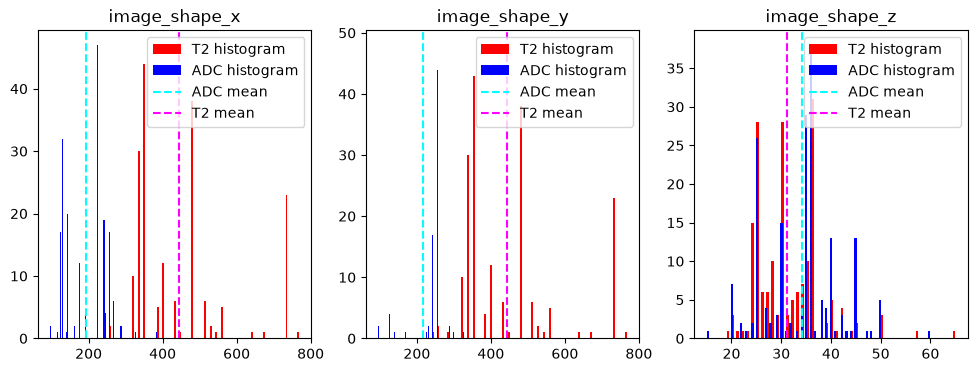

In [103]:
# Graphical
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, shape, adc_mean, t2_mean in zip(axes, shapes, adc_shape_means, t2_shape_means):
    ax.hist(t2_shapes_df[shape], bins=100, color="red", label="T2 histogram")
    ax.hist(adc_shapes_df[shape], bins=100, color="blue", label="ADC histogram")
    ax.axvline(x=adc_mean, color="cyan", linestyle="--", label="ADC mean")
    ax.axvline(x=t2_mean, color="magenta", linestyle="--", label="T2 mean")
    ax.legend()
    ax.set_title(shape)

fig.show()

In [104]:
# Label spesific
labels = manifest_df["response_group"].unique()

In [105]:
t2_responder_df = manifest_df[(manifest_df["modality"] == "T2") & (manifest_df["response_group"] == "responder")][shapes]
t2_nonresponder_df = manifest_df[(manifest_df["modality"] == "T2") & (manifest_df["response_group"] == "nonresponder")][shapes]
t2_intermediate_df = manifest_df[(manifest_df["modality"] == "T2") & (manifest_df["response_group"] == "intermediate")][shapes]

adc_responder_df = manifest_df[(manifest_df["modality"] == "ADC")& (manifest_df["response_group"] == "responder")][shapes]
adc_nonresponder_df = manifest_df[(manifest_df["modality"] == "ADC")& (manifest_df["response_group"] == "nonresponder")][shapes]
adc_intermediate_df = manifest_df[(manifest_df["modality"] == "ADC")& (manifest_df["response_group"] == "intermediate")][shapes]

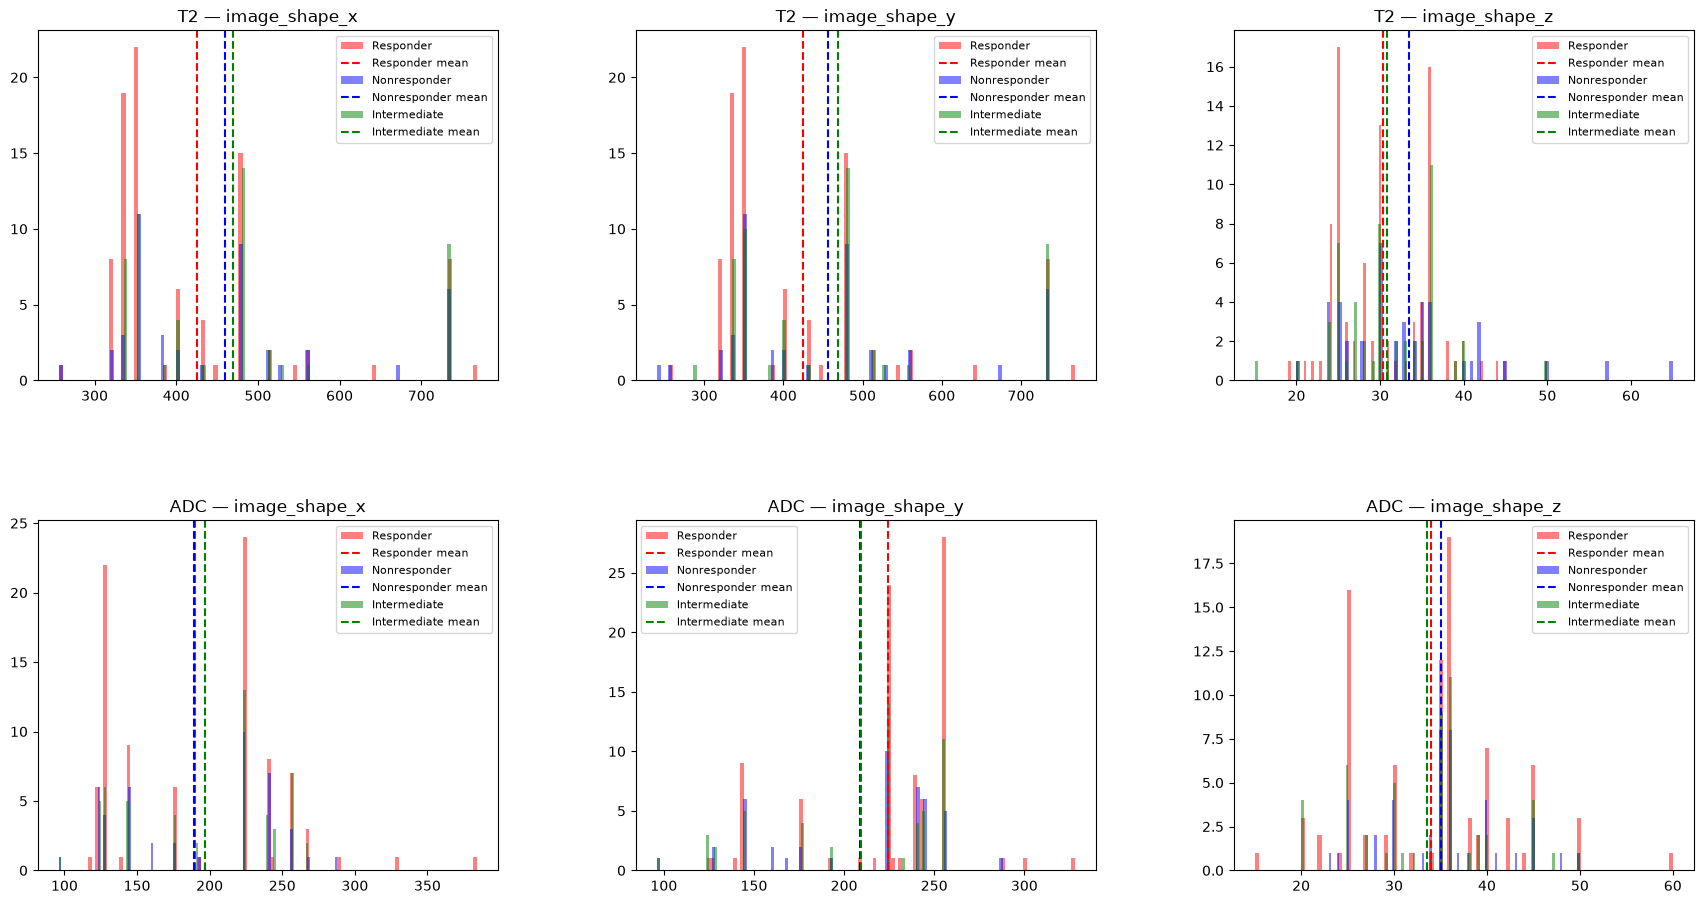

In [106]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# T2
for ax, shape in zip(axes[0], shapes):
    ax.hist(t2_responder_df[shape].dropna(), bins=100,
            color="red", alpha=0.5, label="Responder")
    ax.axvline(x=t2_responder_df[shape].mean(),
                color="red", linestyle="--", label="Responder mean")

    ax.hist(t2_nonresponder_df[shape].dropna(), bins=100,
            color="blue", alpha=0.5, label="Nonresponder")
    ax.axvline(x=t2_nonresponder_df[shape].mean(),
                color="blue", linestyle="--", label="Nonresponder mean")

    ax.hist(t2_intermediate_df[shape].dropna(), bins=100,
            color="green", alpha=0.5, label="Intermediate")
    ax.axvline(x=t2_intermediate_df[shape].mean(),
                color="green", linestyle="--", label="Intermediate mean")

    ax.set_title(f"T2 — {shape}")
    ax.legend(fontsize=8)

# ADC
for ax, shape in zip(axes[1], shapes):
    ax.hist(adc_responder_df[shape].dropna(), bins=100,
            color="red", alpha=0.5, label="Responder")
    ax.axvline(x=adc_responder_df[shape].mean(),
                color="red", linestyle="--", label="Responder mean")

    ax.hist(adc_nonresponder_df[shape].dropna(), bins=100,
            color="blue", alpha=0.5, label="Nonresponder")
    ax.axvline(x=adc_nonresponder_df[shape].mean(),
                color="blue", linestyle="--", label="Nonresponder mean")

    ax.hist(adc_intermediate_df[shape].dropna(), bins=100,
            color="green", alpha=0.5, label="Intermediate")
    ax.axvline(x=adc_intermediate_df[shape].mean(),
                color="green", linestyle="--", label="Intermediate mean")

    ax.set_title(f"ADC — {shape}")
    ax.legend(fontsize=8)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.08,
    top=0.92,
    wspace=0.30,  # sütunlar arası boşluk
    hspace=0.40,  # satırlar arası boşluk
)

plt.show()

### Spacings

In [107]:
spacings = ["image_spacing_x_mm", "image_spacing_y_mm", "image_spacing_z_mm"]

In [108]:
# Statistical
adc_spacing_df = manifest_df[manifest_df["modality"] == "ADC"][spacings]
adc_spacing_desc_df:pd.DataFrame = adc_spacing_df.describe()

t2_spacing_df = manifest_df[manifest_df["modality"] == "T2"][spacings]
t2_spacing_desc_df:pd.DataFrame = t2_spacing_df.describe()

adc_spacing_means = adc_spacing_desc_df.loc["mean"]
t2_spacing_means = t2_spacing_desc_df.loc["mean"]

adc_spacing_desc_df

,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm
count,188.000000,188.000000,188.000000
mean,1.332626,1.332626,4.566809
std,0.415194,0.415194,1.551235
min,0.781250,0.781250,2.999979
25%,0.819672,0.819672,3.000000
50%,1.388889,1.388889,3.600014
75%,1.785714,1.785714,6.599999
max,1.979167,1.979167,8.500000


In [109]:
t2_spacing_desc_df

,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm
count,188.000000,188.000000,188.000000
mean,0.533377,0.533377,4.114692
std,0.229270,0.229270,1.419615
min,0.271739,0.271739,2.999975
25%,0.357143,0.357143,3.000004
50%,0.397727,0.397727,3.500000
75%,0.625000,0.625000,4.125000
max,1.171880,1.171880,9.227272


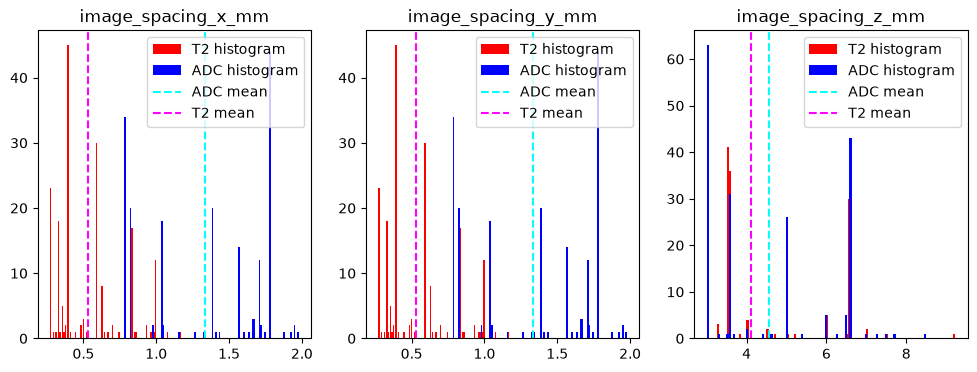

In [110]:
# Graphical
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, spacing, adc_mean, t2_mean in zip(axes, spacings, adc_spacing_means, t2_spacing_means):
    ax.hist(t2_spacing_df[spacing], bins=100, color="red", label="T2 histogram")
    ax.hist(adc_spacing_df[spacing], bins=100, color="blue", label="ADC histogram")
    ax.axvline(x=adc_mean, color="cyan", linestyle="--", label="ADC mean")
    ax.axvline(x=t2_mean, color="magenta", linestyle="--", label="T2 mean")
    ax.legend()
    ax.set_title(spacing)

fig.show()

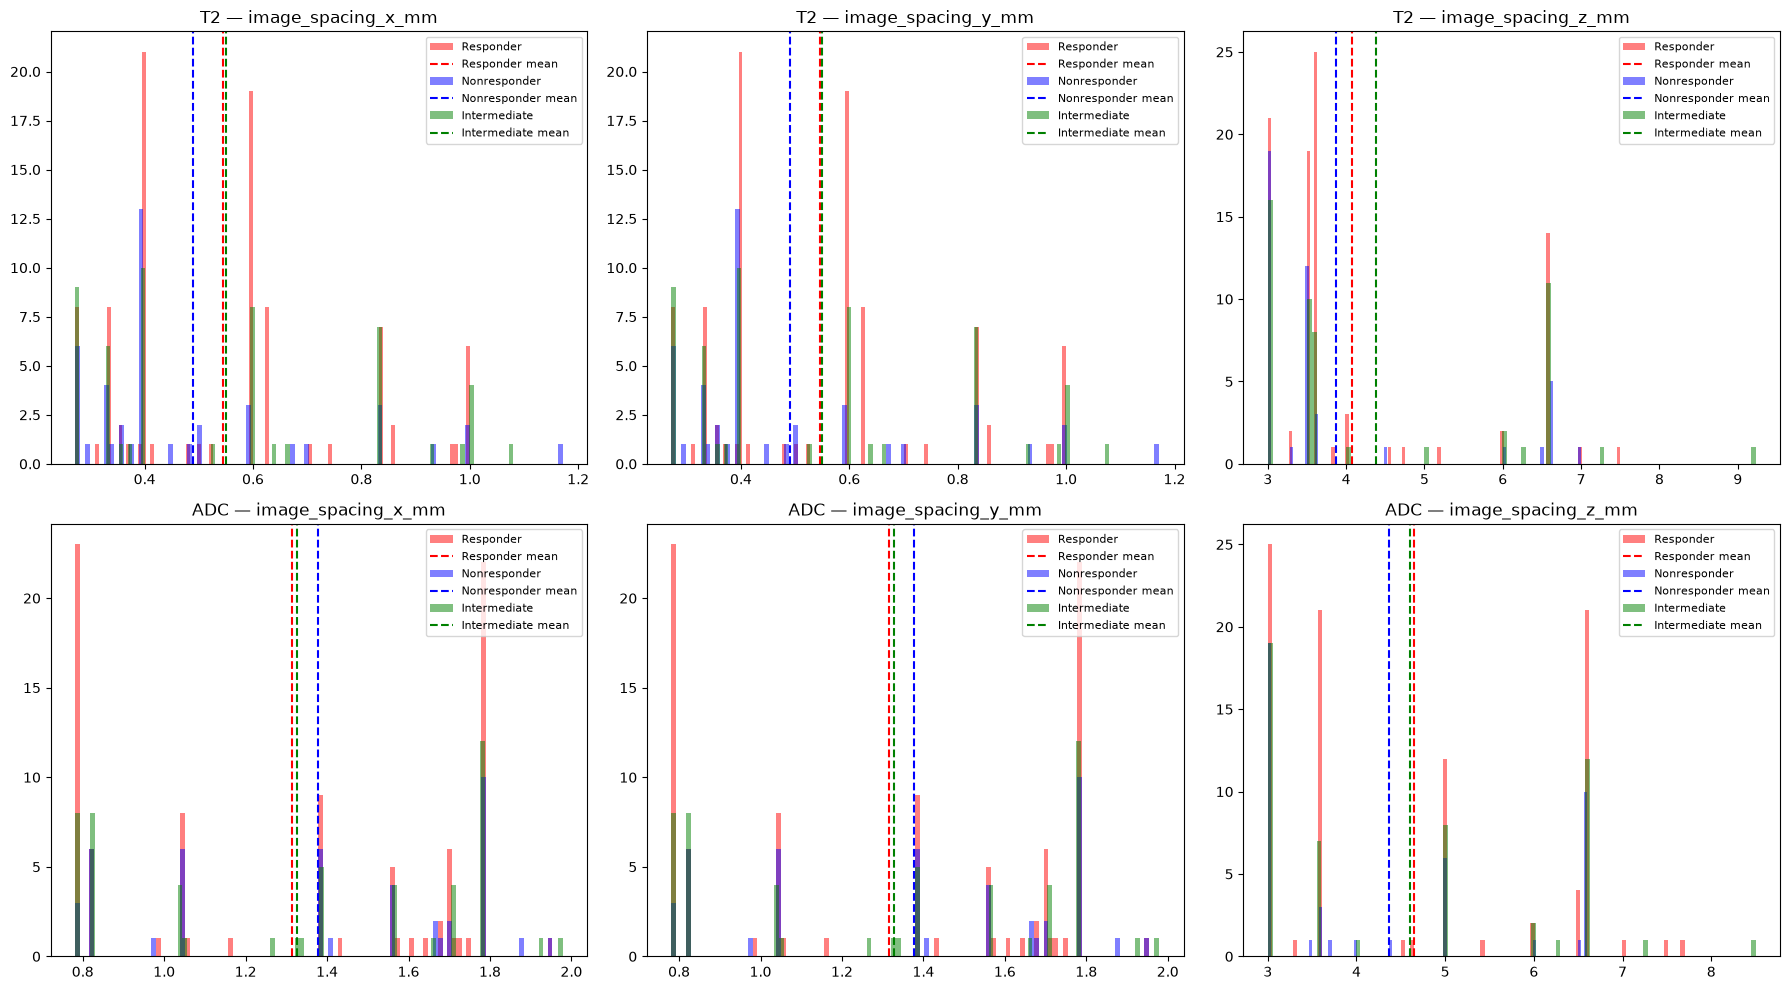

In [111]:
t2_responder_spacing_df = manifest_df[
(manifest_df["modality"] == "T2")
& (manifest_df["response_group"] == "responder")
][spacings]

t2_nonresponder_spacing_df = manifest_df[
(manifest_df["modality"] == "T2")
& (manifest_df["response_group"] == "nonresponder")
][spacings]

t2_intermediate_spacing_df = manifest_df[
(manifest_df["modality"] == "T2")
& (manifest_df["response_group"] == "intermediate")
][spacings]

adc_responder_spacing_df = manifest_df[
(manifest_df["modality"] == "ADC")
& (manifest_df["response_group"] == "responder")
][spacings]

adc_nonresponder_spacing_df = manifest_df[
(manifest_df["modality"] == "ADC")
& (manifest_df["response_group"] == "nonresponder")
][spacings]

adc_intermediate_spacing_df = manifest_df[
(manifest_df["modality"] == "ADC")
& (manifest_df["response_group"] == "intermediate")
][spacings]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# T2 spacing
for ax, spacing in zip(axes[0], spacings):
        ax.hist(t2_responder_spacing_df[spacing].dropna(), bins=100,
                color="red", alpha=0.5, label="Responder")
        ax.axvline(t2_responder_spacing_df[spacing].mean(),
                        color="red", linestyle="--", label="Responder mean")

        ax.hist(t2_nonresponder_spacing_df[spacing].dropna(), bins=100,
                color="blue", alpha=0.5, label="Nonresponder")
        ax.axvline(t2_nonresponder_spacing_df[spacing].mean(),
                        color="blue", linestyle="--", label="Nonresponder mean")

        ax.hist(t2_intermediate_spacing_df[spacing].dropna(), bins=100,
                color="green", alpha=0.5, label="Intermediate")
        ax.axvline(t2_intermediate_spacing_df[spacing].mean(),
                        color="green", linestyle="--", label="Intermediate mean")

        ax.set_title(f"T2 — {spacing}")
        ax.legend(fontsize=8)

# ADC spacing
for ax, spacing in zip(axes[1], spacings):
        ax.hist(adc_responder_spacing_df[spacing].dropna(), bins=100,
                color="red", alpha=0.5, label="Responder")
        ax.axvline(adc_responder_spacing_df[spacing].mean(),
                        color="red", linestyle="--", label="Responder mean")

        ax.hist(adc_nonresponder_spacing_df[spacing].dropna(), bins=100,
                color="blue", alpha=0.5, label="Nonresponder")
        ax.axvline(adc_nonresponder_spacing_df[spacing].mean(),
                        color="blue", linestyle="--", label="Nonresponder mean")

        ax.hist(adc_intermediate_spacing_df[spacing].dropna(), bins=100,
                color="green", alpha=0.5, label="Intermediate")
        ax.axvline(adc_intermediate_spacing_df[spacing].mean(),
                        color="green", linestyle="--", label="Intermediate mean")

        ax.set_title(f"ADC — {spacing}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Conclusion: There is not an obvious seperation between classes. ADC and T2 modility however, seperated clearly from each other, dimensionwise.

**CONCLUSION:** Tumor volumes are changing drastically, processing whole MRI probably would result bad. Instead, cropping only tumor area might eliminate the huge differentiation of size of background data among samples, model should focus only on tumor. However, a **margin** is necessary for model to learn not only tumor area, but also it's effect on the tissue around it.

At the worst scenario, if we realize differentiation among samples negatively affects the model learning, **we might only use closer samples, a subset appox. 50% of the dataset.**